In [7]:
fname = "../data/FileC024.txt"

# look at the first 20 lines

get_ipython().system(' head -20 ./CW_data.txt')

# the pandas library provides useful functions
# for reading, storing, manipulating and writing data
import pandas as pd

#use the pandas library to read the file containing the
#cosmic watch data

data = pd.read_csv(fname,skiprows=7,delim_whitespace=True,
                   names = ['Event', 'Time', 'Date', 'TimeStamp', 'ADC1', 'ADC2', 'SiPM', 'Temp', 'Pressure', 'DeadTime', 'Coincident', 'ID'])

# Make an array that contains all the time stamp data
ts = data["TimeStamp"]

head: ./CW_data.txt: No such file or directory


/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_80693/2360467769.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname,skiprows=7,delim_whitespace=True,


In [83]:
counts = list()
start_time = 100*100*1000
# start_time = 0
for time in range(start_time, start_time + 100*100*1000, 100*1000):
    counts.append(len(ts[(ts >= time) & (ts < time + 100*1000)]))

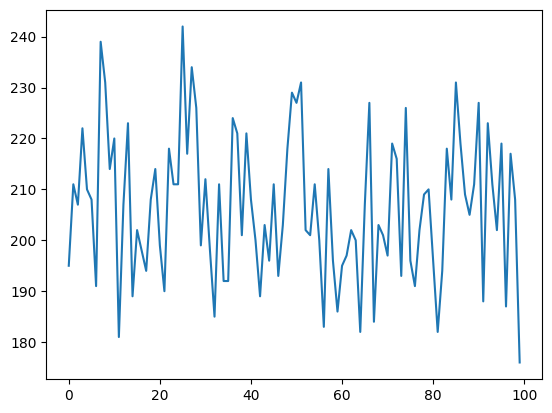

In [85]:
import matplotlib.pyplot as plt

plt.plot(counts)

In [86]:
import numpy as np

average_counts = list()
for i in range(0, len(counts)):
    average_counts.append(sum(counts[0:i+1])/(i+1))

error = list()
for i in range(0, len(counts)):
    error.append(np.std(counts[0:i+1], ddof=1)/np.sqrt(i+1))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Text(0.5, 1.0, 'Second 1000 seconds of Cosmic Watch Data')

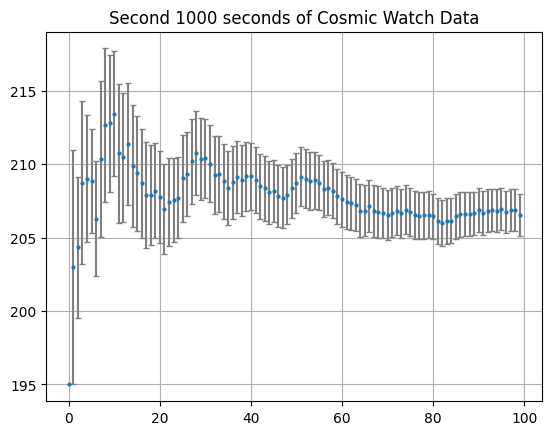

In [87]:
# plt.plot(average_counts)
plt.errorbar(range(0, len(counts)), average_counts, yerr=error, fmt='o', capsize=2, ms=2, ecolor='gray')
plt.grid()
plt.title('Second 1000 seconds of Cosmic Watch Data')

Text(0, 0.5, 'Frequency')

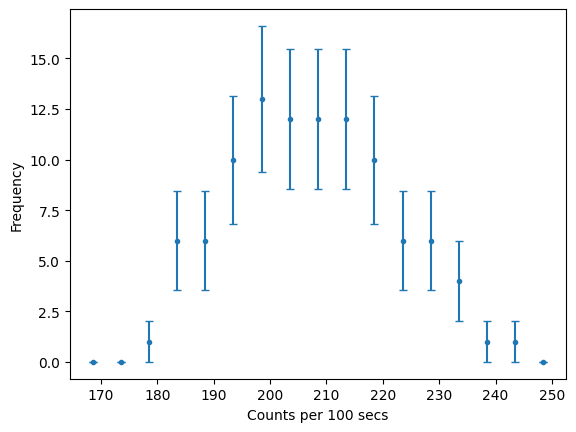

In [93]:
freqs, bin_edges = np.histogram(counts, bins=range(min(counts)-10, max(counts)+10, 5))
bin_centers = 0.5*(bin_edges[1:]+bin_edges[:-1]) # Adding the left edge and right edge together and then dividing by 2
plt.errorbar(bin_centers, freqs, yerr=np.sqrt(freqs), fmt='o', capsize=3, ms=3)
plt.xlabel('Counts per 100 secs')
plt.ylabel('Frequency')

In [94]:
import scipy.optimize as opt
from scipy.special import factorial # NumPy's factorial doesn't work here. Can you figure out why?

# Take out zero bins. The discussion for why I do this is beyond the scope of this intro, ask the instructors
# It's not important to know what's going on in this function if you don't want to know.
# If you do want to know, you'll have to think about it
def delete_zeros(bins,counts,err):
    '''
    Inputs:
    bins = the frequency bin centers
    counts = the frequency data
    err = the error data
    Output:
    new_bins = bin centers, but if the frequency of a bin center is zero the bin is removed
    new_counts = frequency data, but if "                    "
    new_err = error data, but if "                       "
    '''
    zeros = np.where(counts==0) # Find the indices where the frequency data is zero
    mask = np.ones(len(counts),dtype=bool) # create a mask of True values
    mask[zeros[0]] = False # Turn the zero parts of the mask False
    new_counts = counts[mask] # Recreate the bin data without the False parts
    new_bins = bins[mask] # Recreate the frequency data without the False parts
    new_err = err[mask] # Recrete the "      "
    return new_bins, new_counts, new_err

def poisson(x,lam,a):
    '''
    Inputs:
    a = normalization constant
    x = corresponding number of events, should be an array
    lam = expected value, which is equal to the variance for poisson distribution
    Outputs: probability of x number of events occuring, scaled by constant a
    '''
    return a*lam**x*np.exp(-lam)/factorial(x)

In [117]:
pred_counts = poisson(bin_centers,average_counts[-1],sum(freqs) *5) # The *5 is because the bin width is 5

/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_80693/306147392.py:34: RuntimeWarning: overflow encountered in power
  return a*lam**x*np.exp(-lam)/factorial(x)
/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_80693/306147392.py:34: RuntimeWarning: invalid value encountered in divide
  return a*lam**x*np.exp(-lam)/factorial(x)


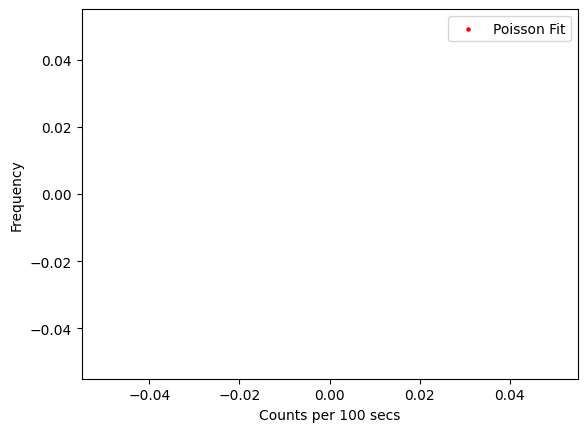

In [118]:
# plt.errorbar(bin_centers, freqs, yerr=np.sqrt(freqs), fmt='o', capsize=3, ms=4, label='Data', zorder=5)
plt.scatter(bin_centers, pred_counts, s=5, color='red', label='Poisson Fit', zorder=1)

plt.xlabel('Counts per 100 secs')
plt.ylabel('Frequency')
plt.legend()

In [108]:
def chisq(func,popt,x,y,sig):
    '''
    Inputs:
    func = function to generate expected value
    x = x data
    y = y data
    sig = sigma data
    Outputs:
    chi2 = chi-squared value
    '''
    expected_vals = func(x, *popt) # Again, better off using *popt
    return np.sum((y-expected_vals)**2/sig**2)

bin_centers_2, freqs_2, sigs_2 = delete_zeros(bin_centers,freqs,np.sqrt(freqs))

chi2 = chisq(poisson,[average_counts[-1], 100],bin_centers_2,freqs_2,sigs_2)
chi2/(len(bin_centers_2)-1) # reduced chi-squared value

/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_80693/306147392.py:34: RuntimeWarning: overflow encountered in power
  return a*lam**x*np.exp(-lam)/factorial(x)
/var/folders/wy/zv30vjj534ldq0pwslz20nkr0000gn/T/ipykernel_80693/306147392.py:34: RuntimeWarning: invalid value encountered in divide
  return a*lam**x*np.exp(-lam)/factorial(x)


nan

In [112]:
def gaussian_approx(x, mu, a):
    return a * 1/np.sqrt(2*np.pi*mu) * np.exp(-(x-mu)**2/(2*mu))

pred_gaussian = gaussian_approx(bin_centers, average_counts[-1], sum(freqs)*5)

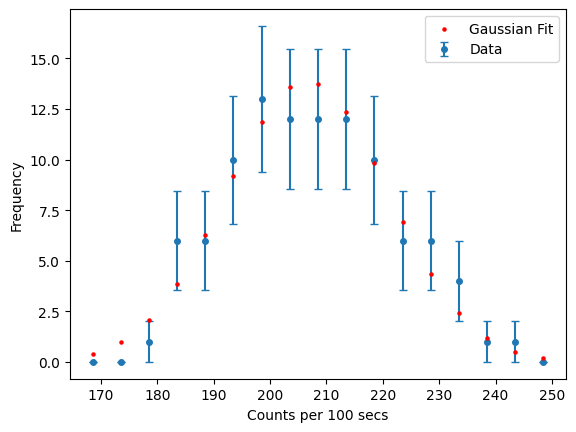

In [115]:
plt.errorbar(bin_centers, freqs, yerr=np.sqrt(freqs), fmt='o', capsize=3, ms=4, label='Data', zorder=5)
plt.scatter(bin_centers, pred_gaussian, s=5, color='red', label='Gaussian Fit', zorder=10)

plt.xlabel('Counts per 100 secs')
plt.ylabel('Frequency')
plt.legend()

In [116]:
chi2 = chisq(gaussian_approx,[average_counts[-1], sum(freqs)],bin_centers_2,freqs_2,sigs_2)
chi2/(len(bin_centers_2)-1) # reduced chi-squared value

4.982877125073301